In [232]:
import h5py as h5
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [233]:
# data_dict['K562'] = h5py.File(self.data_folder + '/K562_DNase_ENCFF257HEE_2kb_4DNFITUOMFUQ_enhancer_promoter_encoding.h5', 'r')
# self.data_dict['GM12878'] = h5py.File(self.data_folder + '/GM12878_DNase_ENCFF020WZB_2kb_4DNFI1UEG1HD_promoter_enhancer_encoding.h5', 'r')
data_h5 = h5.File('../data/K562_DNase_ENCFF257HEE_2kb_4DNFITUOMFUQ_enhancer_promoter_encoding.h5', 'r')

In [234]:
data_h5.keys()

<KeysViewHDF5 ['activity', 'distance', 'ensid', 'hic', 'pe_code']>

In [235]:
# find index where ensid is ENSG00000187905
idx = np.where(data_h5['ensid'][:] == b'ENSG00000187905')[0][0]
idx

np.int64(15569)

In [236]:
idx = 15569
sample_ensid = data_h5['ensid'][idx].decode()
sample_ensid

'ENSG00000187905'

In [237]:
data_h5['pe_code'][idx].shape

(61, 2000, 4)

In [238]:
enhancer_intensity = data_h5['activity'][idx,1:]
enhancer_intensity

array([ 1.067523,  2.95831 ,  0.806705,  2.494484,  1.243623,  2.012474,
       14.561809,  0.75912 ,  2.317925,  1.656551,  4.297424,  1.432482,
        0.93688 ,  0.570605,  3.260576,  0.889175,  4.131723,  1.050445,
        0.984459,  0.719382,  1.911949,  0.99506 ,  0.919373, 46.967707,
        1.377804,  0.826361,  1.221105,  0.814741,  2.682576,  1.430154,
        0.681436,  0.57001 ,  2.410116, 76.509543,  1.478817,  2.002265,
        4.103367,  1.717975,  0.791973,  2.490411,  1.253841,  0.872537,
        1.110926,  0.749995,  1.196535,  0.726934,  0.764507,  6.483523,
        2.978864, 45.567079,  7.096494,  0.924931,  1.893951,  0.782851,
        1.421011,  4.379578,  6.304826,  2.782429,  0.903603,  2.250034])

In [239]:
data_h5['pe_code'][idx][7]

array([[False, False, False,  True],
       [False, False,  True, False],
       [False, False,  True, False],
       ...,
       [ True, False, False, False],
       [False, False,  True, False],
       [False, False, False,  True]])

In [240]:
data_h5['distance'][idx,:]

array([    0. ,  1642. ,  2151. ,  3675. ,  5750.5,  7255. ,  8044. ,
        8081.5, 11426. , 13425.5, 16799.5, 19474. , 19932. , 21090. ,
       22208. , 22780. , 22916. , 24470. , 25568.5, 26810.5, 26918.5,
       28461. , 29200. , 29684.5, 31107.5, 31311. , 32282. , 33521. ,
       34816. , 35972.5, 38040.5, 39257. , 40359. , 41980. , 44148.5,
       44376. , 47152. , 47273. , 47953. , 48400. , 49153. , 49344.5,
       50317.5, 52272. , 55377.5, 56202. , 56398. , 57215. , 57368.5,
       63288. , 63789. , 66044. , 70260. , 72065. , 73373. , 74717.5,
       77952. , 81470.5, 84159. , 85298. , 88400.5])

In [241]:
np.min(data_h5['distance'][:,1:])

np.float64(0.0)

In [242]:
enhancer_distance = data_h5['distance'][idx,1:]
enhancer_distance.shape

(60,)

In [243]:
# count how many enhancers are not 0 in the sample and less than 100000
enhancer_intensity[(enhancer_intensity > 0) & (enhancer_intensity < 100000)].shape[0]

60

Total enhancers: 303813


<Axes: ylabel='Count'>

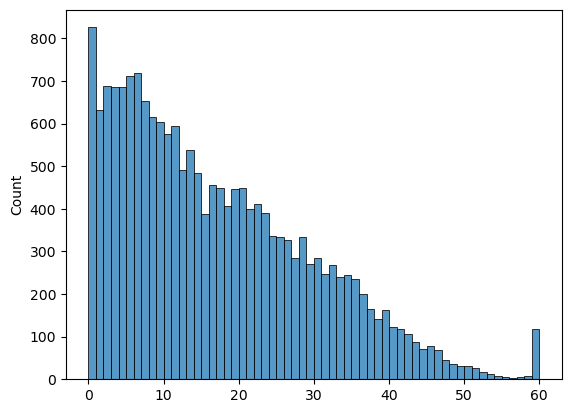

In [244]:
n_enhancers = []
index_max = -1
for idx in range(len(data_h5['ensid'])):
    enhancers = data_h5['distance'][idx,:]
    n_enhancers.append(enhancers[(enhancers > 0) & (enhancers < 100000)].shape[0])

print(f"Total enhancers: {sum(n_enhancers)}")

sns.histplot(n_enhancers, bins=60)

In [245]:
enhancer_preds = pd.read_csv('../data/K562_DNase_ENCFF257HEE_hic_4DNFITUOMFUQ_1MB_ABC_nominated/Gene-enhancer links/EnhancerPredictions.txt', sep='\t')
#enhancer_preds = pd.read_csv('../data/K562_enhancer_gene_links_100kb.tsv', sep='\t')
enhancer_preds = enhancer_preds.rename(columns={'#chr': 'chr'})
enhancer_preds

,chr,start,end,name,TargetGene,TargetGeneTSS,CellType,ABC.Score
0,chr7,31006,31710,intergenic|chr7:31006-31710,ENSG00000177706,192570,K562,0.004602
1,chr7,31006,31710,intergenic|chr7:31006-31710,ENSG00000197461,519217,K562,0.000001
2,chr7,31006,31710,intergenic|chr7:31006-31710,ENSG00000188191,712475,K562,0.000001
3,chr7,31006,31710,intergenic|chr7:31006-31710,ENSG00000164818,726698,K562,0.000588
4,chr7,31006,31710,intergenic|chr7:31006-31710,ENSG00000164828,816642,K562,0.000000
...,...,...,...,...,...,...,...,...
2294541,chr19,58584250,58585301,intergenic|chr19:58584250-58585301,ENSG00000119574,58519796,K562,0.012138
2294542,chr19,58584250,58585301,intergenic|chr19:58584250-58585301,ENSG00000130726,58544455,K562,0.004453
2294543,chr19,58584250,58585301,intergenic|chr19:58584250-58585301,ENSG00000130724,58555104,K562,0.013500
2294544,chr19,58584250,58585301,intergenic|chr19:58584250-58585301,ENSG00000130725,58558921,K562,0.013500


In [246]:
sample_info = enhancer_preds[enhancer_preds['TargetGene'] == sample_ensid][['chr', 'start', 'end', 'name', 'TargetGeneTSS']]
sample_info

,chr,start,end,name,TargetGeneTSS
1739154,chr22,20045664,20046303,genic|chr22:20045664-20046303,21045956
1739196,chr22,20047435,20047935,genic|chr22:20047435-20047935,21045956
1739238,chr22,20049486,20049986,genic|chr22:20049486-20049986,21045956
1739280,chr22,20051998,20053283,genic|chr22:20051998-20053283,21045956
1739322,chr22,20054783,20055283,genic|chr22:20054783-20055283,21045956
...,...,...,...,...,...
1759956,chr22,22039644,22040144,intergenic|chr22:22039644-22040144,21045956
1759974,chr22,22040577,22041077,intergenic|chr22:22040577-22041077,21045956
1759992,chr22,22041820,22042620,intergenic|chr22:22041820-22042620,21045956
1760010,chr22,22042800,22044786,intergenic|chr22:22042800-22044786,21045956


In [247]:
max_distance_down = 0
max_distance_up = 0
for i, row in sample_info.iterrows():
    down_distance = row['start'] - row['TargetGeneTSS']
    up_distance = row['TargetGeneTSS'] - row['end']
    if down_distance > max_distance_down:
        max_distance_down = down_distance
    if up_distance > max_distance_up:
        max_distance_up = up_distance
print(f'Max distance down: {max_distance_down}, Max distance up: {max_distance_up}')

Max distance down: 999530, Max distance up: 999653


In [248]:
enhancer_list = pd.read_csv("../data/K562_DNase_ENCFF257HEE_hic_4DNFITUOMFUQ_1MB_ABC_nominated/DNase_ENCFF257HEE_Neighborhoods/EnhancerList.txt", sep='\t')
enhancer_list = enhancer_list[['chr', 'start', 'end', 'name', 'activity_base', 'activity_base_no_qnorm']]
enhancer_list

,chr,start,end,name,activity_base,activity_base_no_qnorm
0,chr1,585952,586452,intergenic|chr1:585952-586452,0.088073,0.088073
1,chr1,605341,605841,intergenic|chr1:605341-605841,0.355894,0.355894
2,chr1,629686,630186,intergenic|chr1:629686-630186,0.690581,0.690581
3,chr1,633778,634278,intergenic|chr1:633778-634278,1.575716,1.575716
4,chr1,778388,779144,intergenic|chr1:778388-779144,8.205368,8.205368
...,...,...,...,...,...,...
116664,chrY,11329663,11330163,intergenic|chrY:11329663-11330163,0.931987,0.931987
116665,chrY,11333773,11334507,intergenic|chrY:11333773-11334507,0.434642,0.434642
116666,chrY,11712120,11712620,intergenic|chrY:11712120-11712620,0.044362,0.044362
116667,chrY,56849825,56850381,intergenic|chrY:56849825-56850381,0.406223,0.406223


In [249]:
# check if columns activity_base and activity_base_no_qnorm are the same
enhancer_list['activity_base'].equals(enhancer_list['activity_base_no_qnorm'])

True

In [250]:
region_names = set(sample_info['name'].values)

enhancer_list_sample = enhancer_list[enhancer_list['name'].isin(region_names)].copy()
enhancer_list_sample

,chr,start,end,name,activity_base,activity_base_no_qnorm
111209,chr22,20045664,20046303,genic|chr22:20045664-20046303,0.758743,0.758743
111210,chr22,20047435,20047935,genic|chr22:20047435-20047935,0.571288,0.571288
111211,chr22,20049486,20049986,genic|chr22:20049486-20049986,0.357263,0.357263
111212,chr22,20051998,20053283,genic|chr22:20051998-20053283,1.820025,1.820025
111213,chr22,20054783,20055283,genic|chr22:20054783-20055283,0.659328,0.659328
...,...,...,...,...,...,...
111889,chr22,22039644,22040144,intergenic|chr22:22039644-22040144,0.970791,0.970791
111890,chr22,22040577,22041077,intergenic|chr22:22040577-22041077,1.116922,1.116922
111891,chr22,22041820,22042620,intergenic|chr22:22041820-22042620,1.914941,1.914941
111892,chr22,22042800,22044786,intergenic|chr22:22042800-22044786,4.736835,4.736835


In [251]:
sample_match = []
sample_distance = []
for i, row in enhancer_list_sample.iterrows():
    # check if value appears anywhere in the enhancer_intensity
    if row['activity_base'] in enhancer_intensity:
        # find the index of the value in enhancer_intensity
        index = np.where(enhancer_intensity == row['activity_base'])[0][0]
        # check if it has already been matched
        if row['activity_base'] in sample_match:
            print(f"Duplicate match found for {row['activity_base']}")
            sample_match.append(np.nan)
            sample_distance.append(np.nan)
        if row['activity_base'] not in sample_match:
            sample_match.append(row['activity_base'])
            sample_distance.append(enhancer_distance[index])
    else:
        sample_match.append(np.nan)
        sample_distance.append(np.nan)

enhancer_list_sample['known_activity'] = sample_match
enhancer_list_sample['known_distance'] = sample_distance
enhancer_list_sample['used'] = enhancer_list_sample['known_activity'].notna()
enhancer_list_sample

,chr,start,end,name,activity_base,activity_base_no_qnorm,known_activity,known_distance,used
111209,chr22,20045664,20046303,genic|chr22:20045664-20046303,0.758743,0.758743,NaN,NaN,False
111210,chr22,20047435,20047935,genic|chr22:20047435-20047935,0.571288,0.571288,NaN,NaN,False
111211,chr22,20049486,20049986,genic|chr22:20049486-20049986,0.357263,0.357263,NaN,NaN,False
111212,chr22,20051998,20053283,genic|chr22:20051998-20053283,1.820025,1.820025,NaN,NaN,False
111213,chr22,20054783,20055283,genic|chr22:20054783-20055283,0.659328,0.659328,NaN,NaN,False
...,...,...,...,...,...,...,...,...,...
111889,chr22,22039644,22040144,intergenic|chr22:22039644-22040144,0.970791,0.970791,NaN,NaN,False
111890,chr22,22040577,22041077,intergenic|chr22:22040577-22041077,1.116922,1.116922,NaN,NaN,False
111891,chr22,22041820,22042620,intergenic|chr22:22041820-22042620,1.914941,1.914941,NaN,NaN,False
111892,chr22,22042800,22044786,intergenic|chr22:22042800-22044786,4.736835,4.736835,NaN,NaN,False


In [252]:
sample_tss = enhancer_preds[enhancer_preds['TargetGene'] == sample_ensid]['TargetGeneTSS'].values[0]
distance_to_tss = []
for i, row in enhancer_list_sample.iterrows():
    # distance to TSS is the distance from the center of the enhancer to the TSS
    enhancer_center = (row['start'] + row['end']) / 2
    distance = abs(enhancer_center - sample_tss)
    distance_to_tss.append(distance)

enhancer_list_sample['distance_to_tss'] = distance_to_tss
enhancer_list_sample

,chr,start,end,name,activity_base,activity_base_no_qnorm,known_activity,known_distance,used,distance_to_tss
111209,chr22,20045664,20046303,genic|chr22:20045664-20046303,0.758743,0.758743,NaN,NaN,False,999972.5
111210,chr22,20047435,20047935,genic|chr22:20047435-20047935,0.571288,0.571288,NaN,NaN,False,998271.0
111211,chr22,20049486,20049986,genic|chr22:20049486-20049986,0.357263,0.357263,NaN,NaN,False,996220.0
111212,chr22,20051998,20053283,genic|chr22:20051998-20053283,1.820025,1.820025,NaN,NaN,False,993315.5
111213,chr22,20054783,20055283,genic|chr22:20054783-20055283,0.659328,0.659328,NaN,NaN,False,990923.0
...,...,...,...,...,...,...,...,...,...,...
111889,chr22,22039644,22040144,intergenic|chr22:22039644-22040144,0.970791,0.970791,NaN,NaN,False,993938.0
111890,chr22,22040577,22041077,intergenic|chr22:22040577-22041077,1.116922,1.116922,NaN,NaN,False,994871.0
111891,chr22,22041820,22042620,intergenic|chr22:22041820-22042620,1.914941,1.914941,NaN,NaN,False,996264.0
111892,chr22,22042800,22044786,intergenic|chr22:22042800-22044786,4.736835,4.736835,NaN,NaN,False,997837.0


In [253]:
enhancer_list_sample['distance_diff'] = enhancer_list_sample['known_distance'] - abs(enhancer_list_sample['distance_to_tss'])
enhancer_list_sample['region_len'] = enhancer_list_sample['end'] - enhancer_list_sample['start']
enhancer_list_sample

,chr,start,end,name,activity_base,activity_base_no_qnorm,known_activity,known_distance,used,distance_to_tss,distance_diff,region_len
111209,chr22,20045664,20046303,genic|chr22:20045664-20046303,0.758743,0.758743,NaN,NaN,False,999972.5,NaN,639
111210,chr22,20047435,20047935,genic|chr22:20047435-20047935,0.571288,0.571288,NaN,NaN,False,998271.0,NaN,500
111211,chr22,20049486,20049986,genic|chr22:20049486-20049986,0.357263,0.357263,NaN,NaN,False,996220.0,NaN,500
111212,chr22,20051998,20053283,genic|chr22:20051998-20053283,1.820025,1.820025,NaN,NaN,False,993315.5,NaN,1285
111213,chr22,20054783,20055283,genic|chr22:20054783-20055283,0.659328,0.659328,NaN,NaN,False,990923.0,NaN,500
...,...,...,...,...,...,...,...,...,...,...,...,...
111889,chr22,22039644,22040144,intergenic|chr22:22039644-22040144,0.970791,0.970791,NaN,NaN,False,993938.0,NaN,500
111890,chr22,22040577,22041077,intergenic|chr22:22040577-22041077,1.116922,1.116922,NaN,NaN,False,994871.0,NaN,500
111891,chr22,22041820,22042620,intergenic|chr22:22041820-22042620,1.914941,1.914941,NaN,NaN,False,996264.0,NaN,800
111892,chr22,22042800,22044786,intergenic|chr22:22042800-22044786,4.736835,4.736835,NaN,NaN,False,997837.0,NaN,1986


In [254]:
max_used_region_len = enhancer_list_sample['region_len'][enhancer_list_sample['used']].max()
print(f"Max used region length: {max_used_region_len}")

Max used region length: 5935


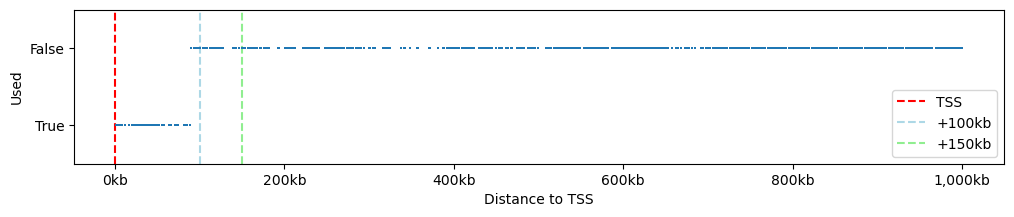

In [255]:
fig, ax = plt.subplots(figsize=(12, 2))
sns.stripplot(data=enhancer_list_sample, x='distance_to_tss', y='used', ax=ax, jitter=False, size=1, marker='s', orient='h')
# vertical line at 0
ax.axvline(x=0, color='red', linestyle='--', label='TSS')
ax.axvline(x=100_000, color='lightblue', linestyle='--', label='+100kb')
ax.axvline(x=150_000, color='lightgreen', linestyle='--', label='+150kb')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: '{:,.0f}'.format(y/1000) + 'kb'))
ax.set_xlabel('Distance to TSS')
ax.set_ylabel('Used')
ax.legend()
plt.show()

In [256]:
max_away = enhancer_list_sample[enhancer_list_sample['used'] == 1]['distance_to_tss'].max()
min_away = enhancer_list_sample[enhancer_list_sample['used'] == 1]['distance_to_tss'].min()
print(f'Max distance to TSS: {max_away}, Min distance to TSS: {min_away}')

Max distance to TSS: 88400.5, Min distance to TSS: 1642.0


# Apply the constraits fresh

In [257]:
def filter_enhancers_by_distance(enhancer_start, tss, max_distance):
    distance = abs(enhancer_start - tss)
    return distance <= max_distance

def filter_enhancers_by_promoter(enhancer_start, tss):
    # enhancers around 2kb of the tss are considered promoters and thus excluded
    return abs(enhancer_start - tss) > 1000

In [258]:
# go through enhancer_preds grouped by target gene and filter for regions by distance and promoter
# chr	start	end	name	TargetGene	TargetGeneTSS
if False:
    filtered_enhancers = []
    for target_gene, group in enhancer_preds.groupby('TargetGene'):
        tss = group['TargetGeneTSS'].values[0]
        group['distance'] = (group['start'] - tss).abs()
        group_sorted = group.sort_values(by='distance')
        n_enhancers = 0
        for _, row in group_sorted.iterrows():
            enhancer_start = row['start']
            if filter_enhancers_by_distance(enhancer_start, tss, 100_000) and filter_enhancers_by_promoter(enhancer_start, tss):
                filtered_tuple = (row['chr'], row['start'], row['end'], row['name'], target_gene, tss)
                filtered_enhancers.append(filtered_tuple)
                n_enhancers += 1
            if n_enhancers >= 60:
                break

    filtered_enhancers_df = pd.DataFrame(filtered_enhancers, columns=['chr', 'start', 'end', 'name', 'TargetGene', 'TargetGeneTSS'])
    filtered_enhancers_df

In [259]:
# merge filtered_enhancher_df with enhancer_list activity_base values (by name)
activity_enhancers_df = filtered_enhancers_df.merge(enhancer_list[['name', 'activity_base']], on='name', how='left')
activity_enhancers_df = activity_enhancers_df.rename(columns={'activity_base': 'original_activity'})
activity_enhancers_df

,chr,start,end,name,TargetGene,TargetGeneTSS,original_activity
0,chrX,100671069,100671638,genic|chrX:100671069-100671638,ENSG00000000003,100636750,0.191760
1,chrX,100674734,100675481,genic|chrX:100674734-100675481,ENSG00000000003,100636750,0.397338
2,chrX,100685550,100686167,genic|chrX:100685550-100686167,ENSG00000000003,100636750,0.555460
3,chrX,100512398,100513000,intergenic|chrX:100512398-100513000,ENSG00000000005,100584935,0.113702
4,chrX,100671069,100671638,genic|chrX:100671069-100671638,ENSG00000000005,100584935,0.191760
...,...,...,...,...,...,...,...
259590,chr15,84111994,84112494,intergenic|chr15:84111994-84112494,ENSG00000259511,84172490,0.411737
259591,chr15,84081736,84082464,intergenic|chr15:84081736-84082464,ENSG00000259511,84172490,0.629803
259592,chr15,84080642,84081142,intergenic|chr15:84080642-84081142,ENSG00000259511,84172490,0.133570
259593,chr11,122202887,122203387,intergenic|chr11:122202887-122203387,ENSG00000259571,122116215,0.284683


<Axes: xlabel='n_enhancers', ylabel='Count'>

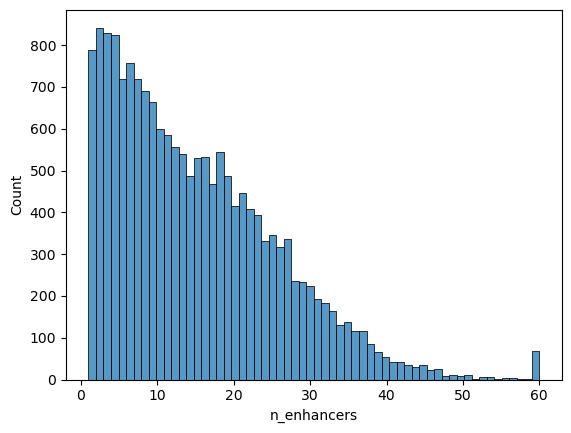

In [260]:
# group by target gene and count how many enhancers are linked to it and histplot it
activity_enhancers_df['n_enhancers'] = activity_enhancers_df.groupby('TargetGene')['name'].transform('count')
# plot the distribution of n_enhancers per gene => ONLY COUNT EACH GENE ONCE
n_enhancers_per_gene = activity_enhancers_df.drop_duplicates(subset=['TargetGene'])['n_enhancers']
sns.histplot(n_enhancers_per_gene, bins=60)

## load our onwn

In [261]:
k562_enhancer_links = pd.read_csv('../data/K562_gene_enhancer_links.csv')
k562_enhancer_links['region_len'] = k562_enhancer_links['end'] - k562_enhancer_links['start']
# sort by max
k562_enhancer_links = k562_enhancer_links.sort_values(by='region_len', ascending=False)
k562_enhancer_links

,chrom,start,end,name,gene_id,tss,region_len
11320,chr9,131025087,131032605,genic|chr9:131025087-131032605,ENSG00000050555,131009186,7518
250366,chr22,21051070,21057005,genic|chr22:21051070-21057005,ENSG00000184436,21001786,5935
36675,chr22,21051070,21057005,genic|chr22:21051070-21057005,ENSG00000099957,21015027,5935
36742,chr22,21051070,21057005,genic|chr22:21051070-21057005,ENSG00000099960,21032560,5935
261438,chr22,21051070,21057005,genic|chr22:21051070-21057005,ENSG00000187905,21045956,5935
...,...,...,...,...,...,...,...
93335,chr6,6315598,6316098,genic|chr6:6315598-6316098,ENSG00000124491,6320661,500
93391,chr6,34459873,34460373,intergenic|chr6:34459873-34460373,ENSG00000124507,34466075,500
93389,chr6,42549346,42549846,intergenic|chr6:42549346-42549846,ENSG00000124496,42451822,500
93386,chr6,42369479,42369979,genic|chr6:42369479-42369979,ENSG00000124496,42451822,500
